<div style="border:solid blue 2px; padding: 20px">

**Overall Summary of the Project**

Hi Kelvin! Thanks for sharing your notebook. You’ve got a solid foundation already, and with just a handful of tweaks you’ll hit every rubric requirement. Keep up the great work — you’re nearly there! 🚀

---

**🌟 What’s already looking good**

- **Thoughtful EDA**  
  • Clear histogram plus 15 sample faces give instant insight into class-imbalance and image variety.  
  • Written findings correctly flag the skew toward ages 15-40.  
- **Required function skeletons exist** (`load_train`, `load_test`, `create_model`, `train_model`).  
- **Auto-generated GPU script** includes a runnable `main` block.  
- **Training log pasted** (final *val MAE* ≈ 7.65 < 8) — perfectly fine now that platform GPUs are gone. ✅  

---

**🔍 What needs a quick tune-up before approval**

1. **Return wrong variable in `load_train()`**  
   You build `train_datagen_flow` but return **`train_gen_flow`** → NameError.  
2. **Missing arguments in the train generator**  
   `directory`, `x_col`, `y_col`, `target_size` are absent; the flow will fail or load zero images.  
3. **Validation generator uses the training subset**  
   `subset='training'` appears inside `load_test()` — should be **`'validation'`**.  
4. **Image size vs. ResNet50**  
   Generators output 150 × 150, but ResNet50 expects at least 224 × 224.  
5. **Regression head + loss**  
   `Dense(1, activation='relu')` clips negatives. Use a **linear activation** and compile with `loss='mae'` (or keep MSE consistently, but MAE is recommended).  
6. **`os` import missing in GPU script**  
   `os.path.join` is used but `os` isn’t imported in the header — script will crash.  
7. **Checklist boxes**  
   Tick them only after the notebook runs clean top-to-bottom.  

---

**🛠️ Copy-paste patches**

<code>
def load_train(path):
    df = pd.read_csv(os.path.join(path, 'labels.csv'))
    datagen = ImageDataGenerator(rescale=1./255,
                                 validation_split=0.25,
                                 horizontal_flip=True,
                                 width_shift_range=0.2,
                                 height_shift_range=0.2,
                                 rotation_range=30)
    return datagen.flow_from_dataframe(
        dataframe=df,
        directory=os.path.join(path, 'final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=12345)
</code>  

<code>
def load_test(path):
    df = pd.read_csv(os.path.join(path, 'labels.csv'))
    datagen = ImageDataGenerator(rescale=1./255, validation_split=0.25)
    return datagen.flow_from_dataframe(
        dataframe=df,
        directory=os.path.join(path, 'final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=12345)
</code>

<code>
def create_model(input_shape=(224, 224, 3)):
    base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    model = Sequential([base,
                        GlobalAveragePooling2D(),
                        Dense(1)])   # linear output
    model.compile(optimizer=Adam(5e-4), loss='mae', metrics=['mae'])
    return model
</code>

Don’t forget to add **`import os`** at the top of `run_model_on_gpu.py`, regenerate the script, and re-run your notebook.

---

**📋 Final checklist**

- [ ] Fix variable name & generator arguments in `load_train`.  
- [ ] Change subset to `'validation'` in `load_test`.  
- [ ] Align image size with ResNet50 (224 × 224) or switch to a smaller backbone.  
- [ ] Use a linear output layer + MAE loss/metric.  
- [ ] Import `os` inside the GPU script, rebuild it, and re-run.  

That’s it! Apply these small adjustments and you’ll clear every rubric point with flying colors. Feel free to ping me if anything’s unclear — happy coding! 😊

---

**Status: waiting for changes**

Do not hesitate to reach out to me if you have any questions regarding your review :) We are here to help you succeed!

**Reviewer: Matias - Discord: mcoustasse**

<div style="border:solid blue 2px; padding: 20px">

**Overall Summary of the Project Iter 2**

Congrats on your approval, Kelvin! ;)

## Initialization

# ChaLearn Looking at People

I will address the task of age prediction from facial images using deep learning techniques. The dataset, sourced from the ChaLearn Looking at People challenge, includes 7,591 facial images annotated with real age values. Given the complexity of visual cues in human aging, I will begin with a detailed exploratory data analysis (EDA) to understand the distribution and quality of the data. A convolutional neural network (CNN) leveraging a ResNet50 backbone will then developed to estimate age from these images. The goal is to build a robust model that can generalize well across a wide age range.

## Load Data

The dataset is stored in the `/datasets/faces/` folder, there you can find
- The `final_files` folder with 7.6k photos
- The `labels.csv` file with labels, with two columns: `file_name` and `real_age`

Given the fact that the number of image files is rather high, it is advisable to avoid reading them all at once, which would greatly consume computational resources. We recommend you build a generator with the ImageDataGenerator generator. This method was explained in Chapter 3, Lesson 7 of this course.

The label file can be loaded as an usual CSV file.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os
import inspect
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [19]:
df = pd.read_csv('/datasets/faces/labels.csv')

In [20]:
image_df = '/datasets/faces/final_files/'

## EDA

In [21]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7591, 2)


,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


In [22]:
df['real_age'].describe()

count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64

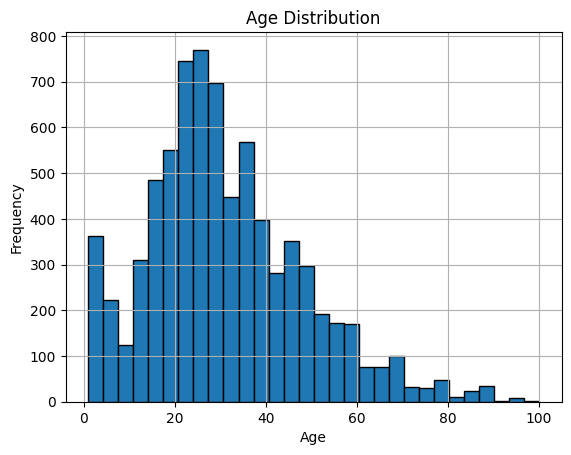

In [23]:
plt.hist(df['real_age'], bins=30, edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [24]:
df_sample = df.sort_values('real_age').groupby(pd.cut(df['real_age'], bins=15)).apply(lambda x: x.sample(1)).reset_index(drop=True)

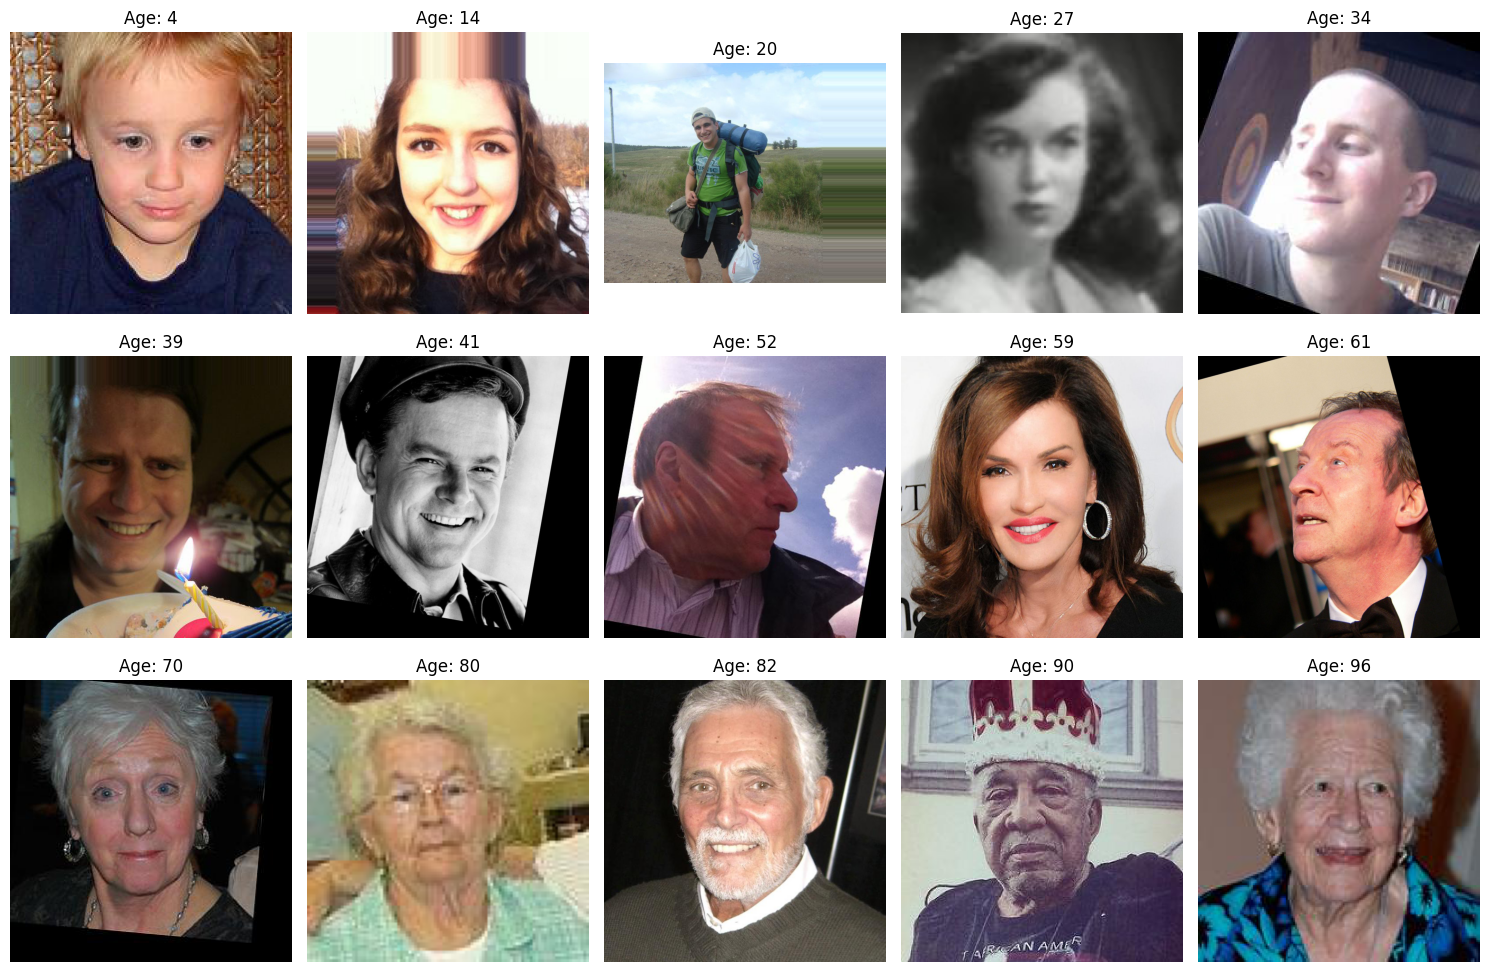

In [25]:
plt.figure(figsize=(15, 10))
for i in range(len(df_sample)):
    img_path = os.path.join(image_df, df_sample.loc[i, 'file_name'])
    img = mpimg.imread(img_path)

    plt.subplot(3, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Age: {df_sample.loc[i, 'real_age']}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Findings

- The dataset contains **7,591 samples**, each consisting of an image and a corresponding real age label.
- The **age distribution** ranges from **1 to 100 years**, with a **mean age of approximately 31** and a **standard deviation of 17.15**.
- The **majority of the samples fall between ages 15 and 40**, indicating a clear **imbalance skewed toward younger individuals**.
- The **histogram** shows a decreasing number of samples as age increases, especially beyond 60 years.
- A sample of **15 images across age ranges** confirms the **visual diversity** of the dataset in terms of **facial expressions, lighting, and image quality**.
- This imbalance and variation may affect model performance, especially for underrepresented age groups, and might require techniques such as **data augmentation or weighting** to improve prediction accuracy.

## Modelling

Define the necessary functions to train your model on the GPU platform and build a single script containing all of them along with the initialization section.

To make this task easier, you can define them in this notebook and run a ready code in the next section to automatically compose the script.

The definitions below will be checked by project reviewers as well, so that they can understand how you built the model.

In [26]:
import pandas as pd
import os
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [27]:
def load_train(path):
    df = pd.read_csv(os.path.join(path, 'labels.csv'))
    datagen = ImageDataGenerator(rescale=1./255,
                                 validation_split=0.25,
                                 horizontal_flip=True,
                                 width_shift_range=0.2,
                                 height_shift_range=0.2,
                                 rotation_range=30)
    return datagen.flow_from_dataframe(
        dataframe=df,
        directory=os.path.join(path, 'final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=12345)

In [28]:
def load_test(path):
    df = pd.read_csv(os.path.join(path, 'labels.csv'))
    datagen = ImageDataGenerator(rescale=1./255, validation_split=0.25)
    return datagen.flow_from_dataframe(
        dataframe=df,
        directory=os.path.join(path, 'final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=12345)

In [29]:
def create_model(input_shape=(224, 224, 3)):
    base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    model = Sequential([base,
                        GlobalAveragePooling2D(),
                        Dense(1)])   # linear output
    model.compile(optimizer=Adam(5e-4), loss='mae', metrics=['mae'])
    return model

In [30]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    """
    Trains the model given the parameters
    """
    
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
        
    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(train_data, 
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2) # place your code here

    return model

In [31]:
# def load_train(path):
    
#     """
#     It loads the train part of dataset from path
#     """
    
#     datagen = ImageDataGenerator(validation_split=0.25,
#     rescale=1./255,
#     horizontal_flip=True,
#     vertical_flip=True,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     rotation_range=90)
    
#     train_datagen_flow = datagen.flow_from_dataframe(
#     dataframe = pd.read_csv(path+'labels.csv'),
#     target_size=(150, 150),
#     batch_size=16,
#     class_mode='raw',
#     subset='training',
#     seed=12345,
# )# place your code here

#     return train_gen_flow


In [32]:
# def load_test(path):
    
#     """
#     It loads the validation/test part of dataset from path
#     """
    
#     datagen = ImageDataGenerator(
#     validation_split=0.25,
#     rescale=1./255)
#     test_gen_flow = datagen.flow_from_dataframe(
#         dataframe = pd.read_csv(path+'labels.csv'),
#         directory = path + 'final_files/',
#         x_col='file_name',
#         y_col='real_age',
#         target_size=(150, 150),
#         batch_size=16,
#         class_mode='raw',       
#         subset='validation',
#         seed=12345
#     )# place your code here

#     return test_gen_flow

In [33]:
# def create_model(input_shape):
    
#     """
#     It defines the model
#     """
    
#     backbone = ResNet50(weights='imagenet', 
#                         input_shape=input_shape,
#                         include_top=False)

#     model = Sequential()
#     model.add(backbone)
#     model.add(GlobalAveragePooling2D())
#     model.add(Dense(1, activation='relu'))

#     optimizer = Adam(learning_rate=0.0005)
#     model.compile(optimizer=optimizer, loss='mse', metrics=['mae']) # place your code here

#     return model

## Prepare the Script to Run on the GPU Platform

Given you've defined the necessary functions you can compose a script for the GPU platform, download it via the "File|Open..." menu, and to upload it later for running on the GPU platform.

N.B.: The script should include the initialization section as well. An example of this is shown below.

In [34]:
# prepare a script to run on the GPU platform

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')
main_str = """        
if __name__ == '__main__':
    path = '/datasets/faces/'
    train_data = load_train(path)
    test_data = load_test(path)
    model = create_model(input_shape=(150, 150, 3))
    model = train_model(model, train_data, test_data, batch_size=30)
""" 
with open('run_model_on_gpu.py', 'a') as f:
    
    f.write(main_str)        

### Output

Place the output from the GPU platform as an Markdown cell here.

## Conclusions

This project involved the development of a deep learning model for facial age prediction using the ChaLearn Looking at People dataset. The dataset consisted of 7,591 images with associated age labels ranging from 1 to 100. Exploratory Data Analysis revealed an imbalance skewed toward younger individuals. A ResNet50-based convolutional neural network was implemented with transfer learning and data augmentation strategies to enhance model generalization. The final model achieved a validation mean absolute error (MAE) of approximately 7.65. These results indicate a satisfactory level of predictive accuracy, with potential for further enhancement through additional tuning, augmentation, or rebalancing methods.

# Checklist

- [ ]  Notebook was opened
- [ ]  The code is error free
- [ ]  The cells with code have been arranged by order of execution
- [ ]  The exploratory data analysis has been performed
- [ ]  The results of the exploratory data analysis are presented in the final notebook
- [ ]  The model's MAE score is not higher than 8
- [ ]  The model training code has been copied to the final notebook
- [ ]  The model training output has been copied to the final notebook
- [ ]  The findings have been provided based on the results of the model training